In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1778201329.230051    4920 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778201329.232336    4920 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778201329.492493    4920 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully!
NumPy version: 2.4.4
TensorFlow version: 2.21.0


I0000 00:00:1778201330.706220    4920 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778201330.707702    4920 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 5. Binary Classification

### Why Linear Regression Fails for Classification

For binary classification ($y \in \{0, 1\}$), linear regression is problematic:
- Predictions can be $< 0$ or $> 1$
- Not probabilistic

Solution: Logistic regression with sigmoid activation:

$$f(x, w) = \sigma(w^Tx) = \frac{1}{1 + e^{-w^Tx}}$$

Binary Cross-Entropy Loss:

$$L(w) = -\frac{1}{N}\sum_{n=1}^N \left[y_n\log(\hat{y}_n) + (1-y_n)\log(1-\hat{y}_n)\right]$$

### Sigmoid Function Visualization

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


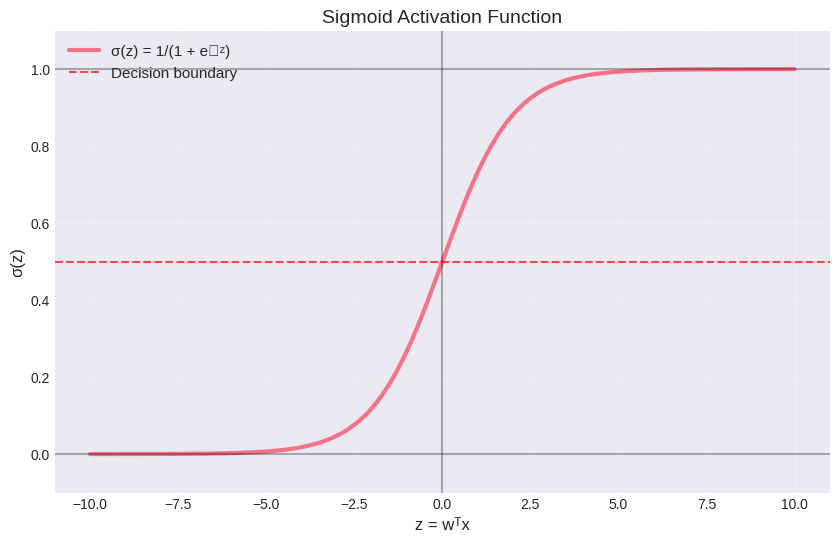

In [2]:
# Visualize sigmoid function
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid, linewidth=3, label='σ(z) = 1/(1 + e⁻ᶻ)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='Decision boundary')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('z = wᵀx', fontsize=12)
plt.ylabel('σ(z)', fontsize=12)
plt.title('Sigmoid Activation Function', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.ylim(-0.1, 1.1)
plt.show()

### Example: Heart Disease Classification

Let's apply binary classification with logistic regression using real patient data from the UCI Heart Disease dataset.

Dataset: Cleveland Heart Disease Database (UCI Machine Learning Repository)

In [3]:
# Load the real UCI Heart Disease dataset from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Read data
df_heart = pd.read_csv(url, names=column_names, na_values='?')

# Clean data: remove rows with missing values
df_heart = df_heart.dropna()

# Convert target to binary: 0 = no disease, 1 = disease present (any severity)
df_heart['target'] = (df_heart['target'] > 0).astype(int)

print("UCI Heart Disease Dataset")
print("="*60)
print(f"Total patients: {len(df_heart)}")
print(f"\nClass distribution:")
print(df_heart['target'].value_counts().sort_index())
print(f"  0: No heart disease")
print(f"  1: Heart disease present")
print(f"\nDataset shape: {df_heart.shape}")
print(f"\nFirst few rows:")
print(df_heart.head())

UCI Heart Disease Dataset
Total patients: 297

Class distribution:
target
0    160
1    137
Name: count, dtype: int64
  0: No heart disease
  1: Heart disease present

Dataset shape: (297, 14)

First few rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [4]:
# Prepare features and target
X_heart_all = df_heart.drop('target', axis=1).values
y_heart = df_heart['target'].values

print("Binary Classification Setup")
print("="*60)
print(f"Number of features: {X_heart_all.shape[1]}")
print(f"Number of samples: {X_heart_all.shape[0]}")
print(f"Output classes: 2 (0=No disease, 1=Disease)")
print(f"\nFeature names:")
for i, name in enumerate(df_heart.columns[:-1]):
    print(f"  {i+1}. {name}")

Binary Classification Setup
Number of features: 13
Number of samples: 297
Output classes: 2 (0=No disease, 1=Disease)

Feature names:
  1. age
  2. sex
  3. cp
  4. trestbps
  5. chol
  6. fbs
  7. restecg
  8. thalach
  9. exang
  10. oldpeak
  11. slope
  12. ca
  13. thal


In [5]:
# Train logistic regression
# Split data
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_heart_all, y_heart, test_size=0.25, random_state=42, stratify=y_heart
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

# Train model
log_reg_full = LogisticRegression(max_iter=1000)
log_reg_full.fit(X_train_scaled, y_train)

# Predictions
y_pred_train_full = log_reg_full.predict(X_train_scaled)
y_pred_test_full = log_reg_full.predict(X_test_scaled)

# Evaluate
train_acc_full = accuracy_score(y_train, y_pred_train_full)
test_acc_full = accuracy_score(y_test, y_pred_test_full)

print(f"Train Accuracy: {train_acc_full:.3f}")
print(f"Test Accuracy: {test_acc_full:.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_full))

Train Accuracy: 0.838
Test Accuracy: 0.853

Confusion Matrix:
[[35  5]
 [ 6 29]]


---
## 6. Multi-class Classification: MNIST

### Loading MNIST Dataset

MNIST: 70,000 handwritten digits (28×28 grayscale images)

Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Pixel range: [0, 255]


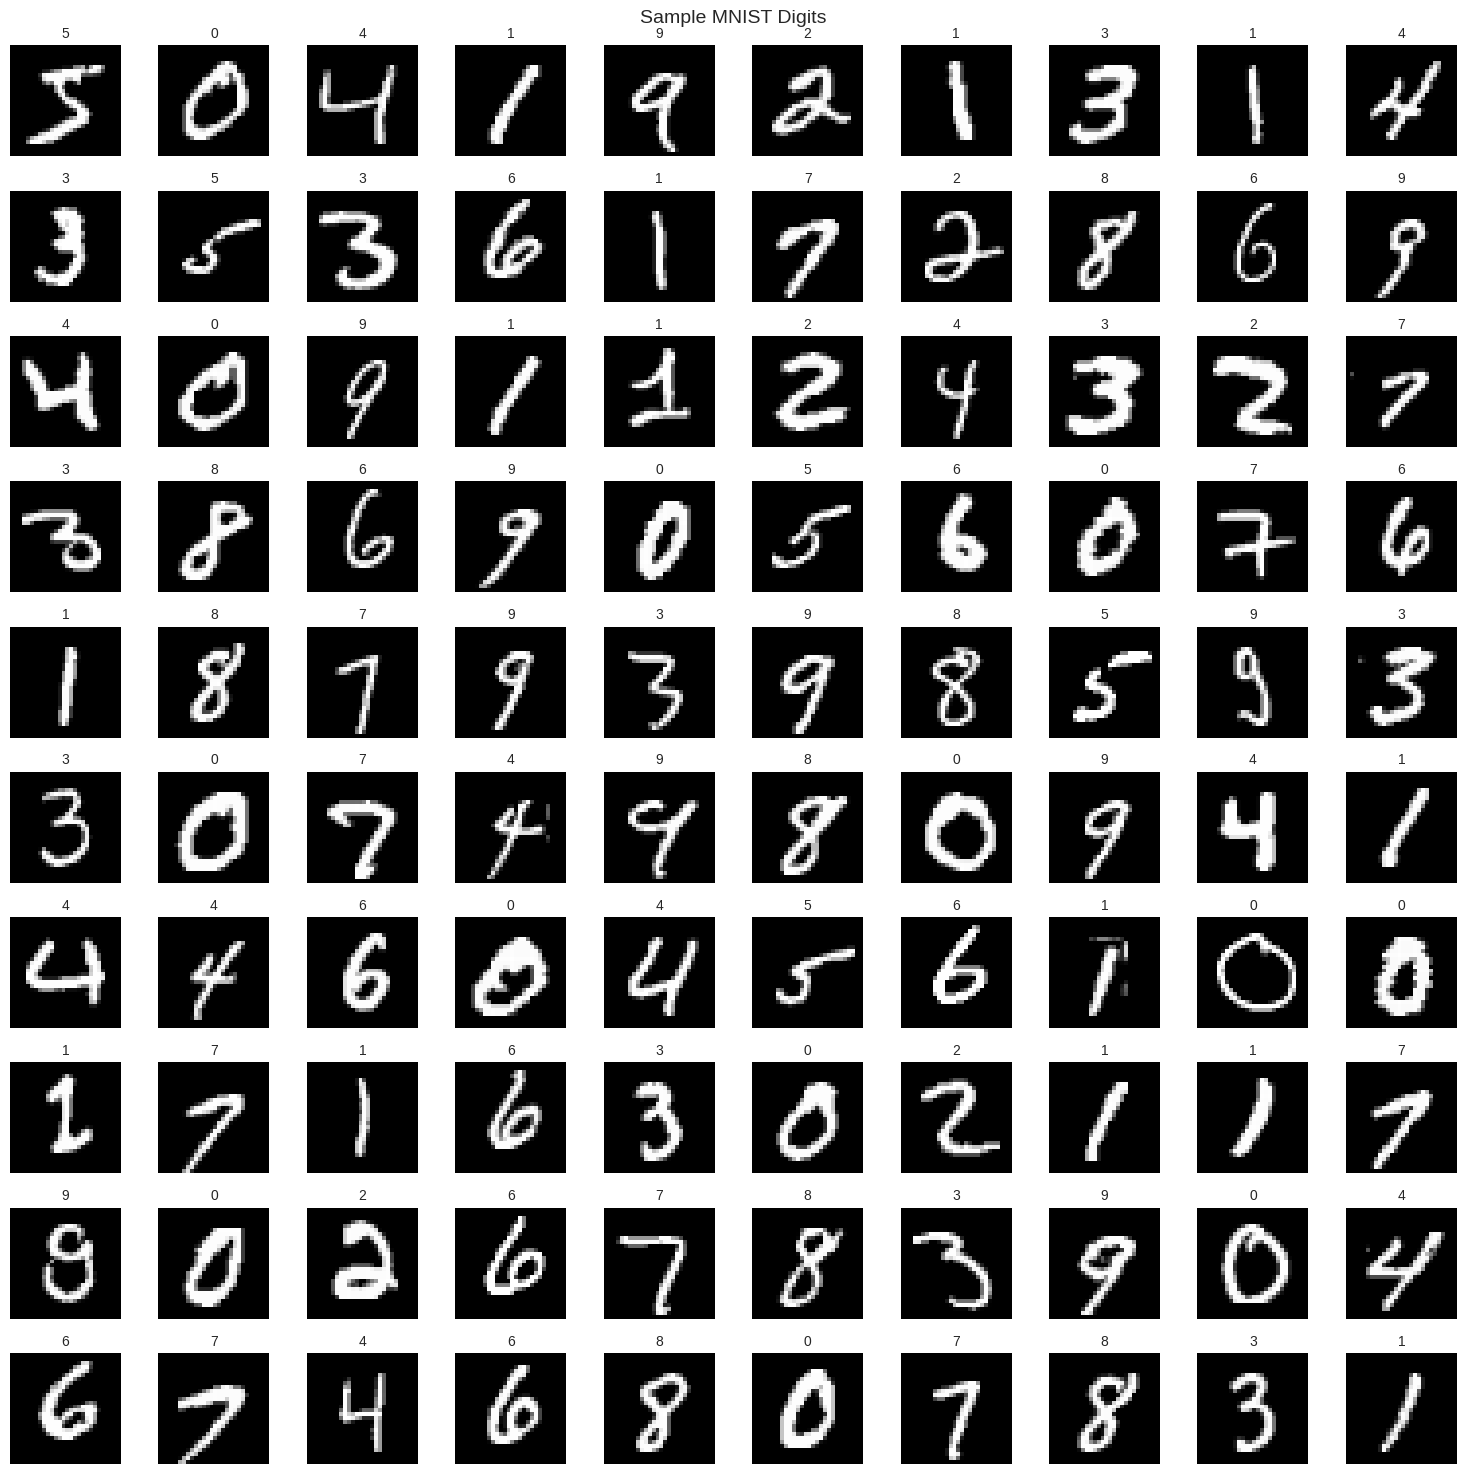

In [6]:
# Load MNIST dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

print(f"Training set: {X_train_mnist.shape}")
print(f"Test set: {X_test_mnist.shape}")
print(f"Pixel range: [{X_train_mnist.min()}, {X_train_mnist.max()}]")

# Visualize samples
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for i in range(100):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_train_mnist[i], cmap='gray')
    ax.set_title(f'{y_train_mnist[i]}', fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Explore the data structure in detail
print("="*60)
print("MNIST Data Structure")
print("="*60)

print("\n1. Data Types:")
print(f"   X_train_mnist type: {type(X_train_mnist)}")
print(f"   y_train_mnist type: {type(y_train_mnist)}")
print(f"   X_train_mnist dtype: {X_train_mnist.dtype}")
print(f"   y_train_mnist dtype: {y_train_mnist.dtype}")

print("\n2. Shapes:")
print(f"   X_train_mnist.shape: {X_train_mnist.shape}")
print(f"   → {X_train_mnist.shape[0]} images, each {X_train_mnist.shape[1]}×{X_train_mnist.shape[2]} pixels")
print(f"   y_train_mnist.shape: {y_train_mnist.shape}")

print("\n3. Value Ranges:")
print(f"   Pixel values: [{X_train_mnist.min()}, {X_train_mnist.max()}]")
print(f"   Labels: {np.unique(y_train_mnist)}")

print("\n4. Example: First Digit (a '{0}')".format(y_train_mnist[0]))
print(f"   Shape: {X_train_mnist[0].shape}")
print(f"   First 5 rows of pixel values:")
print(X_train_mnist[0][:5])
print(f"   Non-zero pixels: {np.count_nonzero(X_train_mnist[0])} / {X_train_mnist[0].size}")

print("\n6. Label Distribution:")
unique, counts = np.unique(y_train_mnist, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"   Digit {digit}: {count} samples ({count/len(y_train_mnist)*100:.1f}%)")

print("="*60)

MNIST Data Structure

1. Data Types:
   X_train_mnist type: <class 'numpy.ndarray'>
   y_train_mnist type: <class 'numpy.ndarray'>
   X_train_mnist dtype: uint8
   y_train_mnist dtype: uint8

2. Shapes:
   X_train_mnist.shape: (60000, 28, 28)
   → 60000 images, each 28×28 pixels
   y_train_mnist.shape: (60000,)

3. Value Ranges:
   Pixel values: [0, 255]
   Labels: [0 1 2 3 4 5 6 7 8 9]

4. Example: First Digit (a '5')
   Shape: (28, 28)
   First 5 rows of pixel values:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
   Non-zero pixels: 166 / 784

6. Label Distribution:
   Digit 0: 5923 samples (9.9%)
   Digit 1: 6742 samples (11.2%)
   Digit 2: 5958 samples (9.9%)
   Digit 3: 6131 samples (10.2%)
   Digit 4: 5842 samples (9.7%)
   Digit 5: 5

### Softmax and Categorical Cross-Entropy

For multi-class classification ($K$ classes):

Softmax: For each sample, convert logits to probabilities
$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}}$$

where $z_k = w_k^T\phi(x)$ are the logits for class $k=1,\ldots,K$.

Categorical Cross-Entropy: Average over all $N$ training samples
$$L = -\frac{1}{N}\sum_{n=1}^N\sum_{k=1}^K y_{nk}\log(\hat{y}_{nk})$$

where $y_{nk} \in \{0,1\}$ is 1 if sample $n$ belongs to class $k$, and 0 otherwise.

In [8]:
# Preprocess data for linear model
X_train_flat = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_flat = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0

# Use subset for faster training
n_samples = 10000
X_train_subset = X_train_flat[:n_samples]
y_train_subset = y_train_mnist[:n_samples]

# Train logistic regression (softmax for multi-class)
print("Training linear model (Softmax Regression)...")
linear_classifier = LogisticRegression(max_iter=100, solver='saga', verbose=1)
linear_classifier.fit(X_train_subset, y_train_subset)

# Evaluate
train_acc = linear_classifier.score(X_train_subset, y_train_subset)
test_acc = linear_classifier.score(X_test_flat, y_test_mnist)

Training linear model (Softmax Regression)...
Epoch 1, change: 1
Epoch 2, change: 0.17191136
Epoch 3, change: 0.10260957
Epoch 4, change: 0.084209137
Epoch 5, change: 0.070033126
Epoch 6, change: 0.060958933
Epoch 7, change: 0.057643089
Epoch 8, change: 0.052386325
Epoch 9, change: 0.048935715
Epoch 10, change: 0.04705793
Epoch 11, change: 0.043900426
Epoch 12, change: 0.04083759
Epoch 13, change: 0.038588505
Epoch 14, change: 0.035630573
Epoch 15, change: 0.034263089
Epoch 16, change: 0.032166239
Epoch 17, change: 0.03026282
Epoch 18, change: 0.028775271
Epoch 19, change: 0.027294487
Epoch 20, change: 0.026329562
Epoch 21, change: 0.024592845
Epoch 22, change: 0.023785714
Epoch 23, change: 0.022141885
Epoch 24, change: 0.021538617
Epoch 25, change: 0.020067429
Epoch 26, change: 0.019489365
Epoch 27, change: 0.01831672
Epoch 28, change: 0.017735051
Epoch 29, change: 0.016958179
Epoch 30, change: 0.016782792
Epoch 31, change: 0.015422358
Epoch 32, change: 0.014902883
Epoch 33, change: 0

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


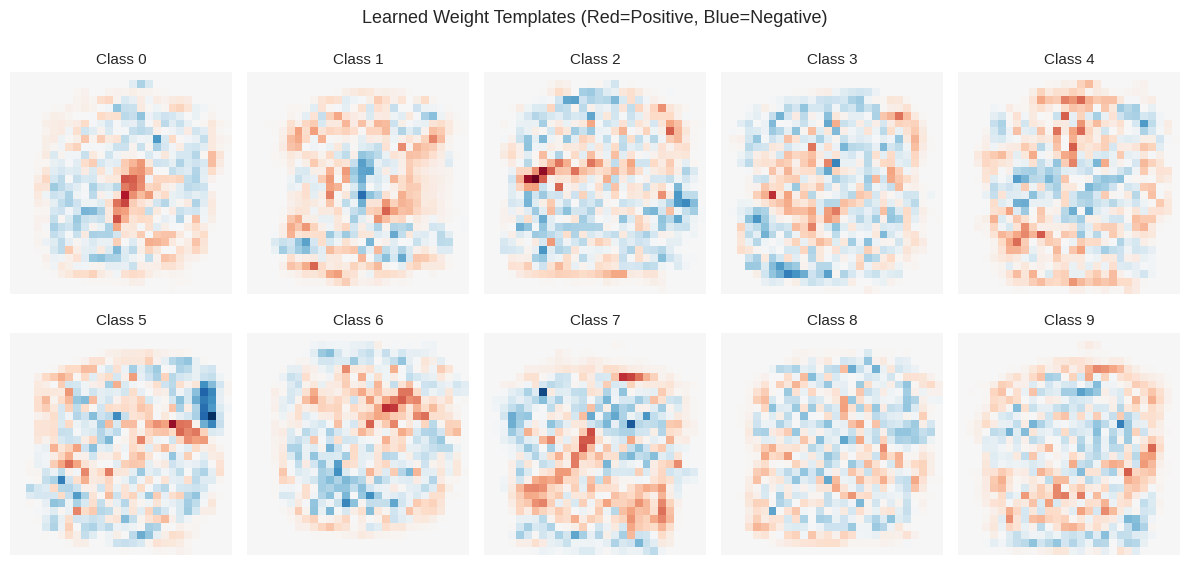

In [9]:
# Visualize learned weights
weights = linear_classifier.coef_.reshape(10, 28, 28)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    im = ax.imshow(weights[i], cmap='RdBu', vmin=-weights.max(), vmax=weights.max())
    ax.set_title(f'Class {i}', fontsize=11)
    ax.axis('off')

plt.suptitle('Learned Weight Templates (Red=Positive, Blue=Negative)', fontsize=13)
plt.tight_layout()
plt.show()

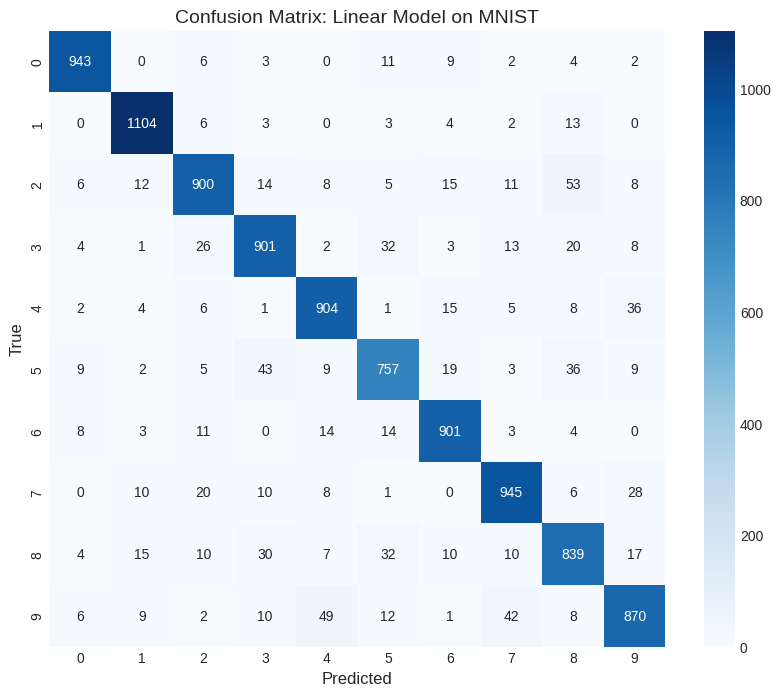


Most confused pairs:
  2 ↔ 8: 63 errors
  3 ↔ 5: 75 errors
  4 ↔ 9: 85 errors
  5 ↔ 8: 68 errors
  7 ↔ 9: 70 errors


In [10]:
# Confusion matrix
y_pred = linear_classifier.predict(X_test_flat)
cm = confusion_matrix(y_test_mnist, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix: Linear Model on MNIST', fontsize=14)
plt.show()

print("\nMost confused pairs:")
for i in range(10):
    for j in range(i+1, 10):
        if cm[i, j] + cm[j, i] > 50:
            print(f"  {i} ↔ {j}: {cm[i, j] + cm[j, i]} errors")

---
## 7. Multi-Layer Perceptrons: Breaking Linear Barriers

### The XOR Problem

XOR is not linearly separable. No linear model can solve it!

Linear model accuracy: 50%


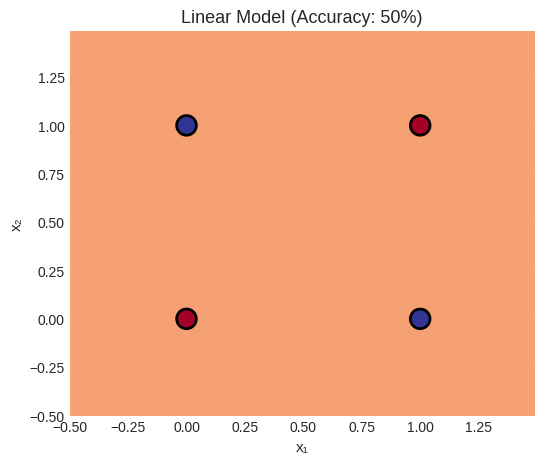

In [11]:
# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Linear model (Logistic Regression)
log_reg_xor = LogisticRegression()
log_reg_xor.fit(X_xor, y_xor)
acc_linear_xor = log_reg_xor.score(X_xor, y_xor)
print(f"Linear model accuracy: {acc_linear_xor:.0%}")

# Visualize linear model decision boundary
h = 0.01
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

plt.figure(figsize=(6, 5))
Z1 = log_reg_xor.predict(np.c_[xx.ravel(), yy.ravel()])
Z1 = Z1.reshape(xx.shape)
plt.contourf(xx, yy, Z1, alpha=0.8, cmap='RdYlBu')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, s=200,
           edgecolors='black', linewidth=2, cmap='RdYlBu')
plt.title(f'Linear Model (Accuracy: {acc_linear_xor:.0%})', fontsize=13)
plt.xlabel('x₁', fontsize=11)
plt.ylabel('x₂', fontsize=11)
plt.show()

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778201349.317254    4920 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


MLP accuracy: 100%


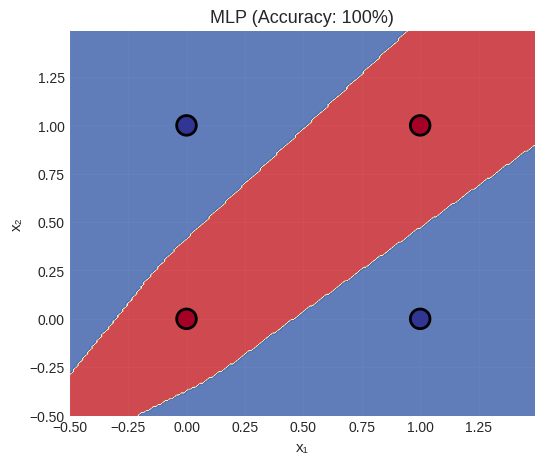

In [12]:
# MLP model
mlp_xor = keras.Sequential([
    layers.Dense(8, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

mlp_xor.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp_xor.fit(X_xor, y_xor, epochs=1000, verbose=0)

acc_mlp_xor = mlp_xor.evaluate(X_xor, y_xor, verbose=0)[1]
print(f"MLP accuracy: {acc_mlp_xor:.0%}")

# Visualize MLP decision boundary
plt.figure(figsize=(6, 5))
Z2 = mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
Z2 = (Z2 > 0.5).astype(int).reshape(xx.shape)
plt.contourf(xx, yy, Z2, alpha=0.8, cmap='RdYlBu')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, s=200,
           edgecolors='black', linewidth=2, cmap='RdYlBu')
plt.title(f'MLP (Accuracy: {acc_mlp_xor:.0%})', fontsize=13)
plt.xlabel('x₁', fontsize=11)
plt.ylabel('x₂', fontsize=11)
plt.show()

### ReLU Activation

Modern MLPs typically use ReLU (Rectified Linear Unit):

$$\text{ReLU}(z) = \max(0, z)$$

/tmp/ipykernel_4920/4090424959.py:29: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


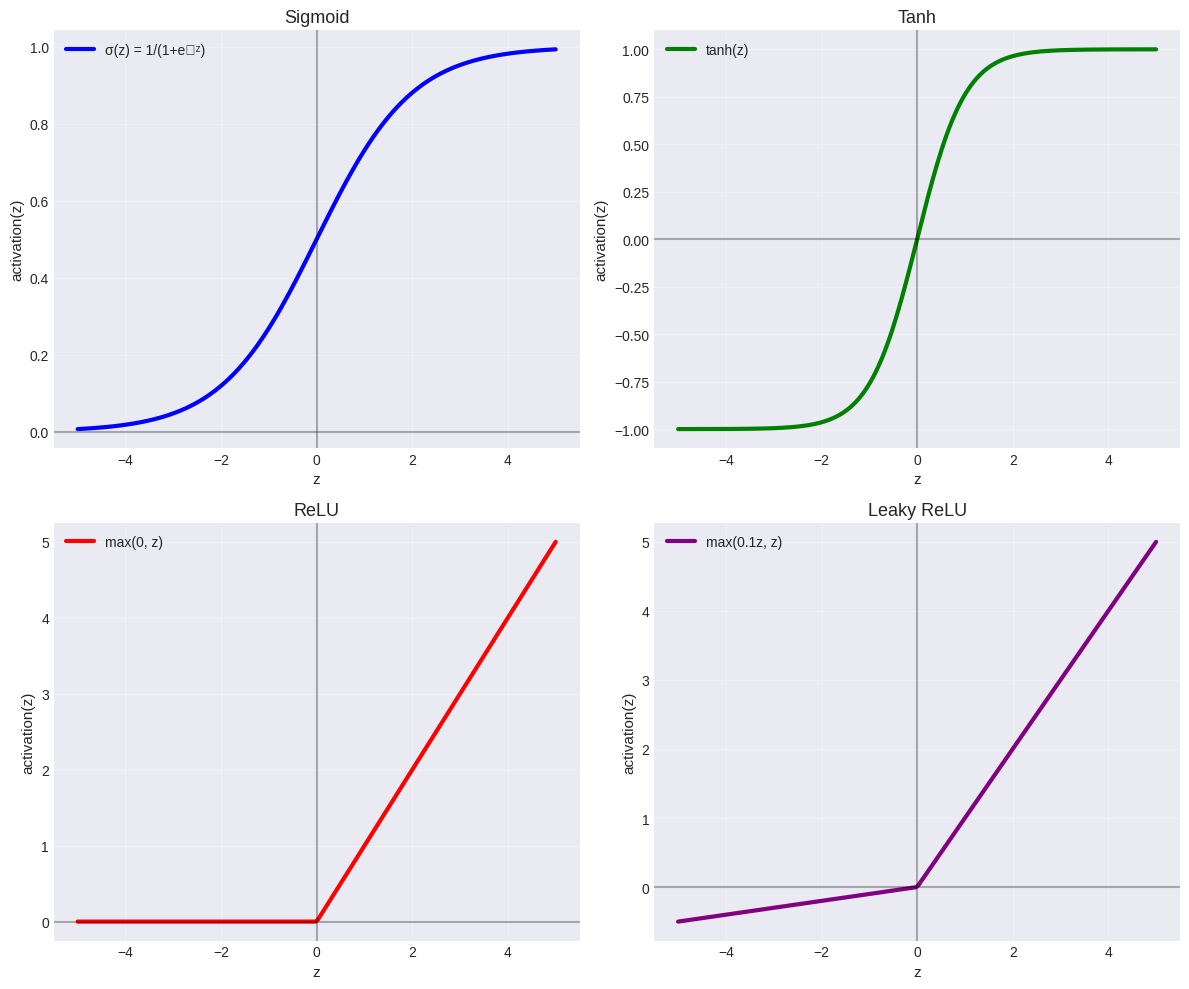

In [13]:
# Compare activation functions
z = np.linspace(-5, 5, 200)

sigmoid_act = 1 / (1 + np.exp(-z))
tanh_act = np.tanh(z)
relu_act = np.maximum(0, z)
leaky_relu_act = np.where(z > 0, z, 0.1*z)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

activations = [
    (sigmoid_act, 'Sigmoid', 'σ(z) = 1/(1+e⁻ᶻ)', 'blue'),
    (tanh_act, 'Tanh', 'tanh(z)', 'green'),
    (relu_act, 'ReLU', 'max(0, z)', 'red'),
    (leaky_relu_act, 'Leaky ReLU', 'max(0.1z, z)', 'purple')
]

for idx, (act, name, formula, color) in enumerate(activations):
    ax = axes[idx // 2, idx % 2]
    ax.plot(z, act, color=color, linewidth=3, label=formula)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('z', fontsize=11)
    ax.set_ylabel('activation(z)', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Training Hyperparameters

**Epochs:** Number of times the model sees the entire training dataset.
- More epochs = more learning (but risk of overfitting)

**Batch Size:** Number of samples processed before updating weights.
- Smaller batches = noisier but more frequent updates
- Larger batches = smoother but slower learning

**Learning Rate:** How big the weight update steps are.
- Too high: unstable training
- Too low: very slow convergence

### MLP on MNIST

Let's see how an MLP dramatically improves performance on MNIST.

In [14]:
# Prepare data
X_train_nn = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_nn = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0

y_train_cat = to_categorical(y_train_mnist, 10)
y_test_cat = to_categorical(y_test_mnist, 10)

# Build MLP
mlp_mnist = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mlp_mnist.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_mnist.summary()

# Train
history = mlp_mnist.fit(
    X_train_nn, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)

# Evaluate
test_loss, test_acc = mlp_mnist.evaluate(X_test_nn, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.2%}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9019 - loss: 0.3567 - val_accuracy: 0.9605 - val_loss: 0.1394
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9561 - loss: 0.1506 - val_accuracy: 0.9698 - val_loss: 0.1038
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.1041 - val_accuracy: 0.9733 - val_loss: 0.0889
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9771 - loss: 0.0779 - val_accuracy: 0.9767 - val_loss: 0.0819
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9820 - loss: 0.0604 - val_accuracy: 0.9760 - val_loss: 0.0794
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9865 - loss: 0.0467 - val_accuracy: 0.9767 - val_loss: 0.0824
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9895 - loss: 0.0368 - val_accuracy: 0.9763 - val_loss: 0.0857
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9923 - loss: 0.0285 - val_accuracy: 0.

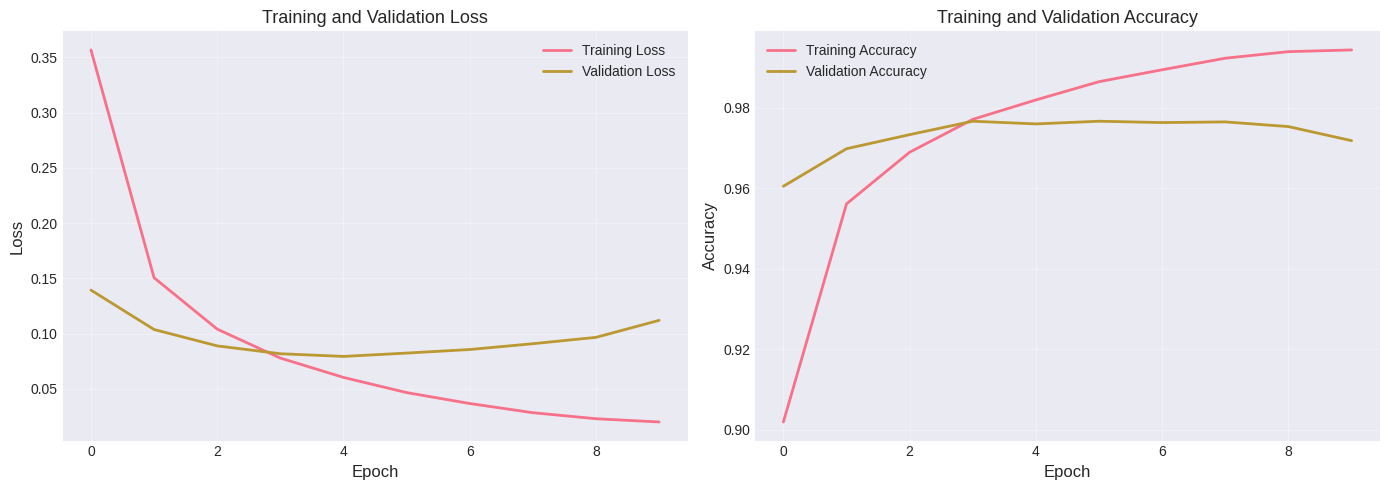

In [15]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualizing Predictions

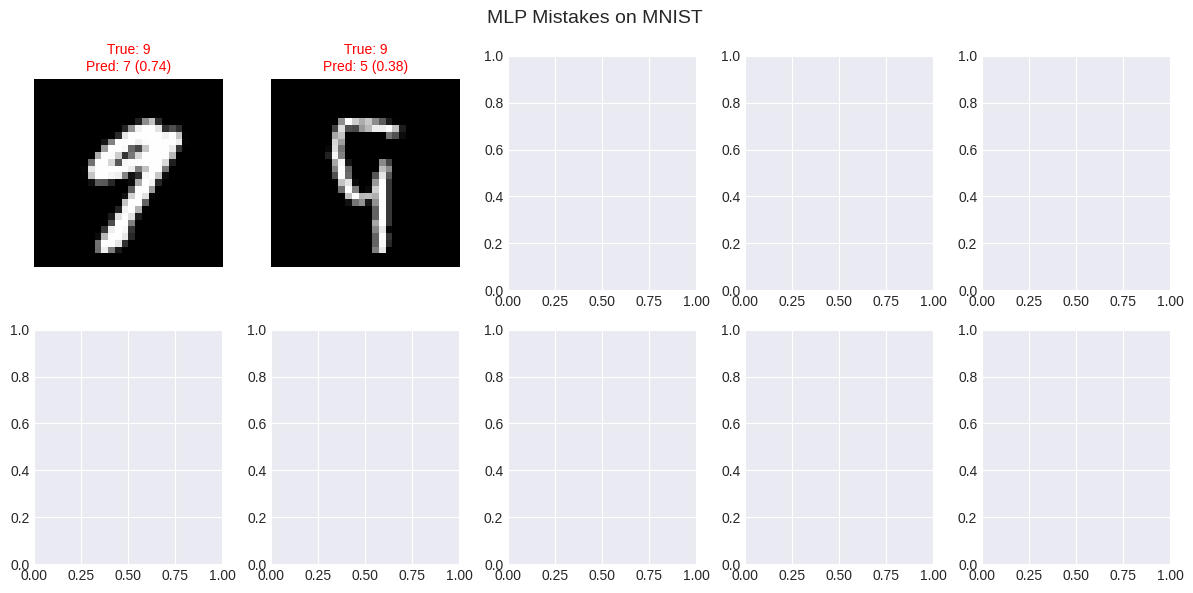

In [16]:
# Show some predictions
predictions = mlp_mnist.predict(X_test_nn[:100], verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test_mnist[:100]

# Find some mistakes
mistakes = np.where(predicted_classes != true_classes)[0]

if len(mistakes) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    for i, idx in enumerate(mistakes[:10]):
        ax = axes[i // 5, i % 5]
        ax.imshow(X_test_mnist[idx], cmap='gray')
        true_label = true_classes[idx]
        pred_label = predicted_classes[idx]
        confidence = predictions[idx][pred_label]
        ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.2f})',
                    fontsize=10, color='red')
        ax.axis('off')
    plt.suptitle('MLP Mistakes on MNIST', fontsize=14)
    plt.tight_layout()
    plt.show()

---
## 8. Universal Function Approximation

Universal Approximation Theorem: A neural network with a single hidden layer can approximate any continuous function to arbitrary precision.

Let's demonstrate this by approximating complex functions.

### Approximating sin(x) with MLPs

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_

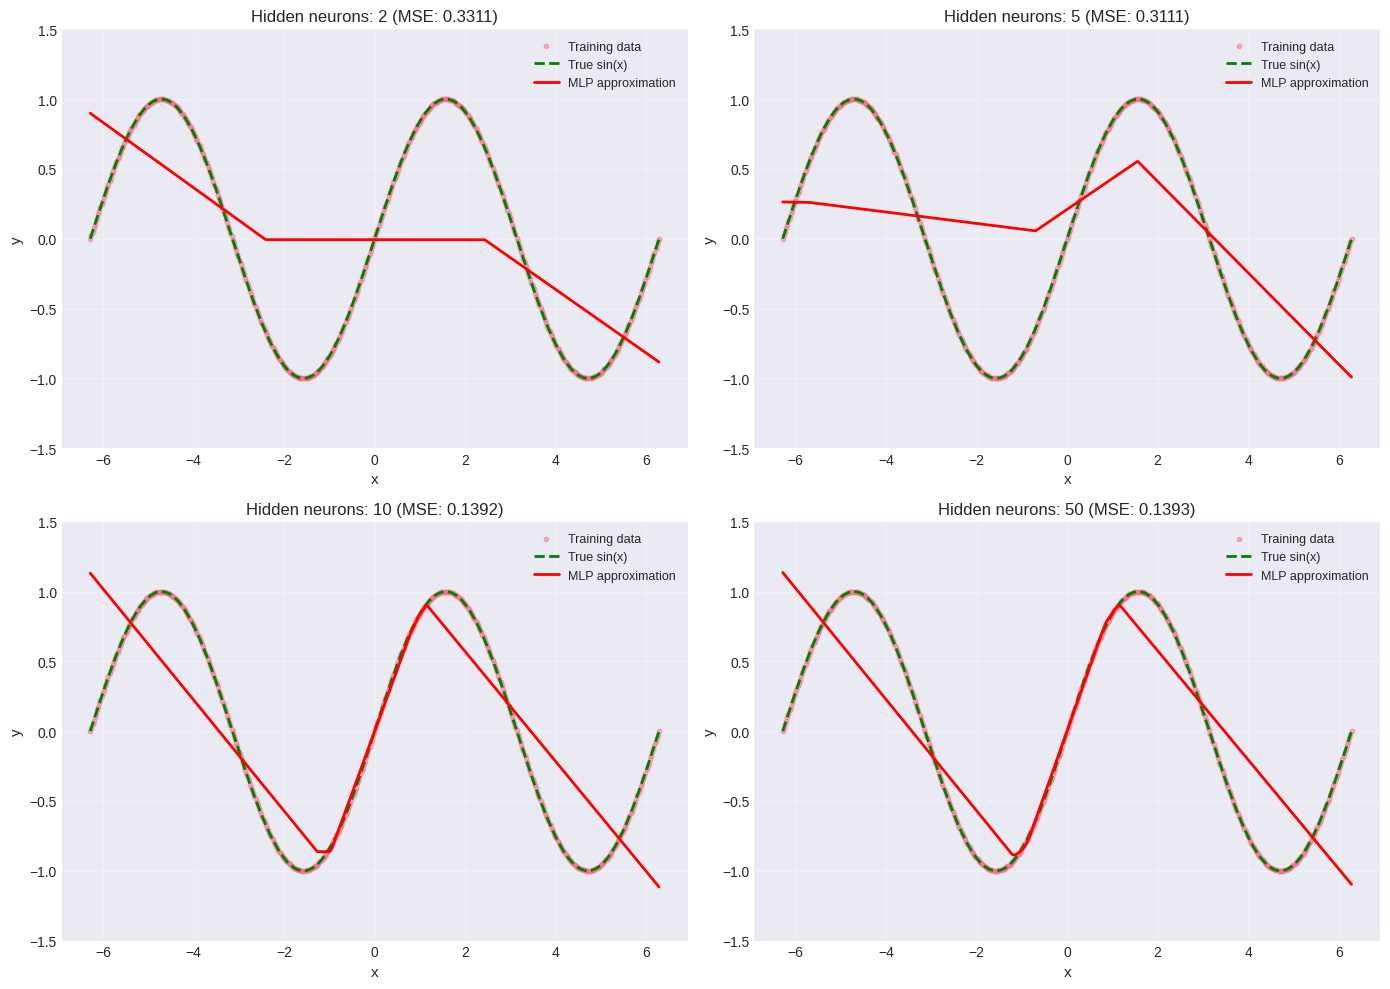

In [17]:
# Generate training data
X_func = np.linspace(-2*np.pi, 2*np.pi, 500).reshape(-1, 1)
y_func_sin = np.sin(X_func).ravel()

# Test different hidden layer sizes
hidden_sizes = [2, 5, 10, 50]
X_test_func = np.linspace(-2*np.pi, 2*np.pi, 1000).reshape(-1, 1)
y_test_true = np.sin(X_test_func).ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, hidden_size in enumerate(hidden_sizes):
    # Build MLP
    model = keras.Sequential([
        layers.Dense(hidden_size, activation='relu', input_shape=(1,)),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_func, y_func_sin, epochs=200, verbose=0)

    # Predict
    y_pred = model.predict(X_test_func, verbose=0).ravel()
    mse = mean_squared_error(y_test_true, y_pred)

    # Plot
    axes[idx].scatter(X_func, y_func_sin, alpha=0.5, s=10, label='Training data')
    axes[idx].plot(X_test_func, y_test_true, 'g--', linewidth=2, label='True sin(x)')
    axes[idx].plot(X_test_func, y_pred, 'r-', linewidth=2, label='MLP approximation')
    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('y', fontsize=11)
    axes[idx].set_title(f'Hidden neurons: {hidden_size} (MSE: {mse:.4f})', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

=== Effect of Network Depth ===



/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_

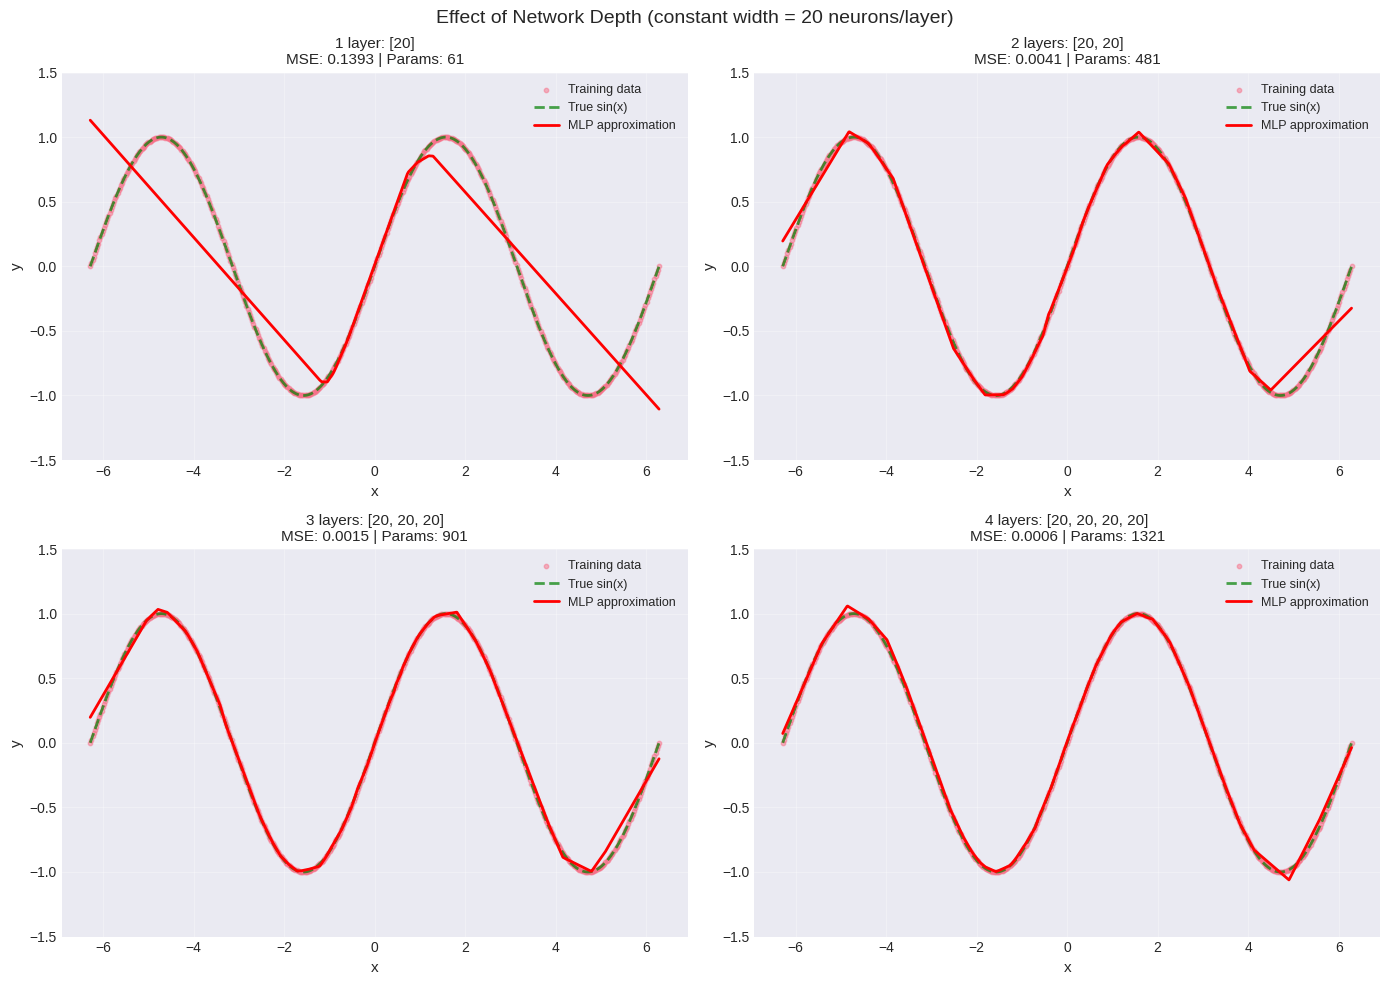

In [18]:
# Now test different depths (number of layers)
# Keep width constant at 20 neurons per layer, vary depth
print("=== Effect of Network Depth ===\n")

architectures = [
    ([20], "1 layer: [20]"),
    ([20, 20], "2 layers: [20, 20]"),
    ([20, 20, 20], "3 layers: [20, 20, 20]"),
    ([20, 20, 20, 20], "4 layers: [20, 20, 20, 20]")
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (hidden_layers, desc) in enumerate(architectures):
    # Build MLP with variable depth
    model = keras.Sequential()
    model.add(layers.Dense(hidden_layers[0], activation='relu', input_shape=(1,)))

    for units in hidden_layers[1:]:
        model.add(layers.Dense(units, activation='relu'))

    model.add(layers.Dense(1))  # Output layer

    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_func, y_func_sin, epochs=200, verbose=0)

    # Predict
    y_pred = model.predict(X_test_func, verbose=0).ravel()
    mse = mean_squared_error(y_test_true, y_pred)
    final_loss = history.history['loss'][-1]

    # Count total parameters
    total_params = model.count_params()

    # Plot
    axes[idx].scatter(X_func, y_func_sin, alpha=0.5, s=10, label='Training data')
    axes[idx].plot(X_test_func, y_test_true, 'g--', linewidth=2, label='True sin(x)', alpha=0.7)
    axes[idx].plot(X_test_func, y_pred, 'r-', linewidth=2, label='MLP approximation')
    axes[idx].set_xlabel('x', fontsize=11)
    axes[idx].set_ylabel('y', fontsize=11)
    axes[idx].set_title(f'{desc}\nMSE: {mse:.4f} | Params: {total_params}', fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1.5, 1.5)

plt.suptitle('Effect of Network Depth (constant width = 20 neurons/layer)', fontsize=14)
plt.tight_layout()
plt.show()

### 2D Function Approximation

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


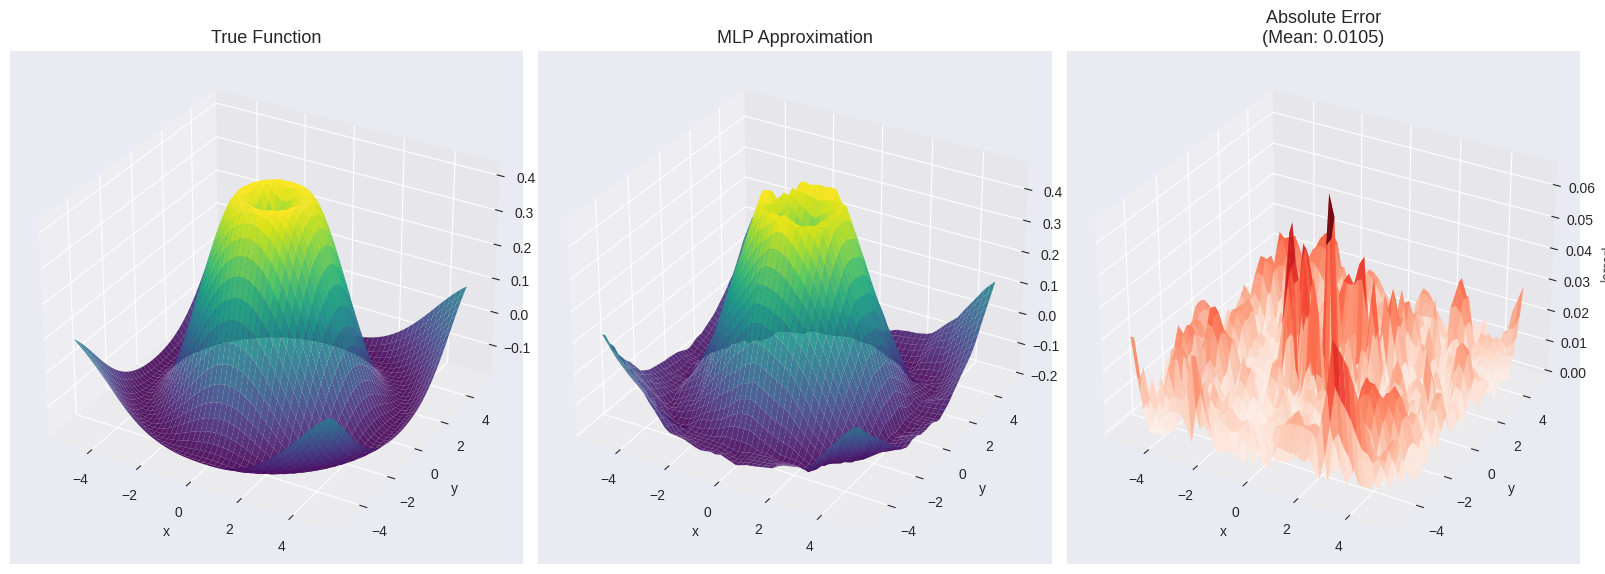


Mean Absolute Error: 0.01049
Max Absolute Error: 0.06568

✓ MLPs can approximate complex multi-dimensional functions!


In [19]:
# Create 2D function
def func_2d(x, y):
    return np.sin(np.sqrt(x**2 + y**2)) / (1 + np.sqrt(x**2 + y**2))

# Generate training data
n = 1000
X_2d_train = np.random.uniform(-5, 5, (n, 2))
y_2d_train = func_2d(X_2d_train[:, 0], X_2d_train[:, 1])

# Create test grid
x_range = np.linspace(-5, 5, 50)
y_range = np.linspace(-5, 5, 50)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
Z_true = func_2d(X_grid, Y_grid)

# Train MLP
mlp_2d = keras.Sequential([
    layers.Dense(50, activation='relu', input_shape=(2,)),
    layers.Dense(50, activation='relu'),
    layers.Dense(1)
])

mlp_2d.compile(optimizer='adam', loss='mse')
mlp_2d.fit(X_2d_train, y_2d_train, epochs=100, verbose=0)

# Predict
X_test_2d = np.c_[X_grid.ravel(), Y_grid.ravel()]
Z_pred = mlp_2d.predict(X_test_2d, verbose=0).reshape(X_grid.shape)

# Visualize
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_true, cmap='viridis', alpha=0.9)
ax1.set_title('True Function', fontsize=13)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_pred, cmap='viridis', alpha=0.9)
ax2.set_title('MLP Approximation', fontsize=13)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

ax3 = fig.add_subplot(133, projection='3d')
error = np.abs(Z_true - Z_pred)
ax3.plot_surface(X_grid, Y_grid, error, cmap='Reds', alpha=0.9)
ax3.set_title(f'Absolute Error\n(Mean: {error.mean():.4f})', fontsize=13)
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('|error|')

plt.tight_layout()
plt.show()

print(f"\nMean Absolute Error: {error.mean():.5f}")
print(f"Max Absolute Error: {error.max():.5f}")
print("\n✓ MLPs can approximate complex multi-dimensional functions!")

## 9. Deep Learning on CIFAR-10

CIFAR-10: 60,000 color images (32×32) in 10 classes

/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training set: (50000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


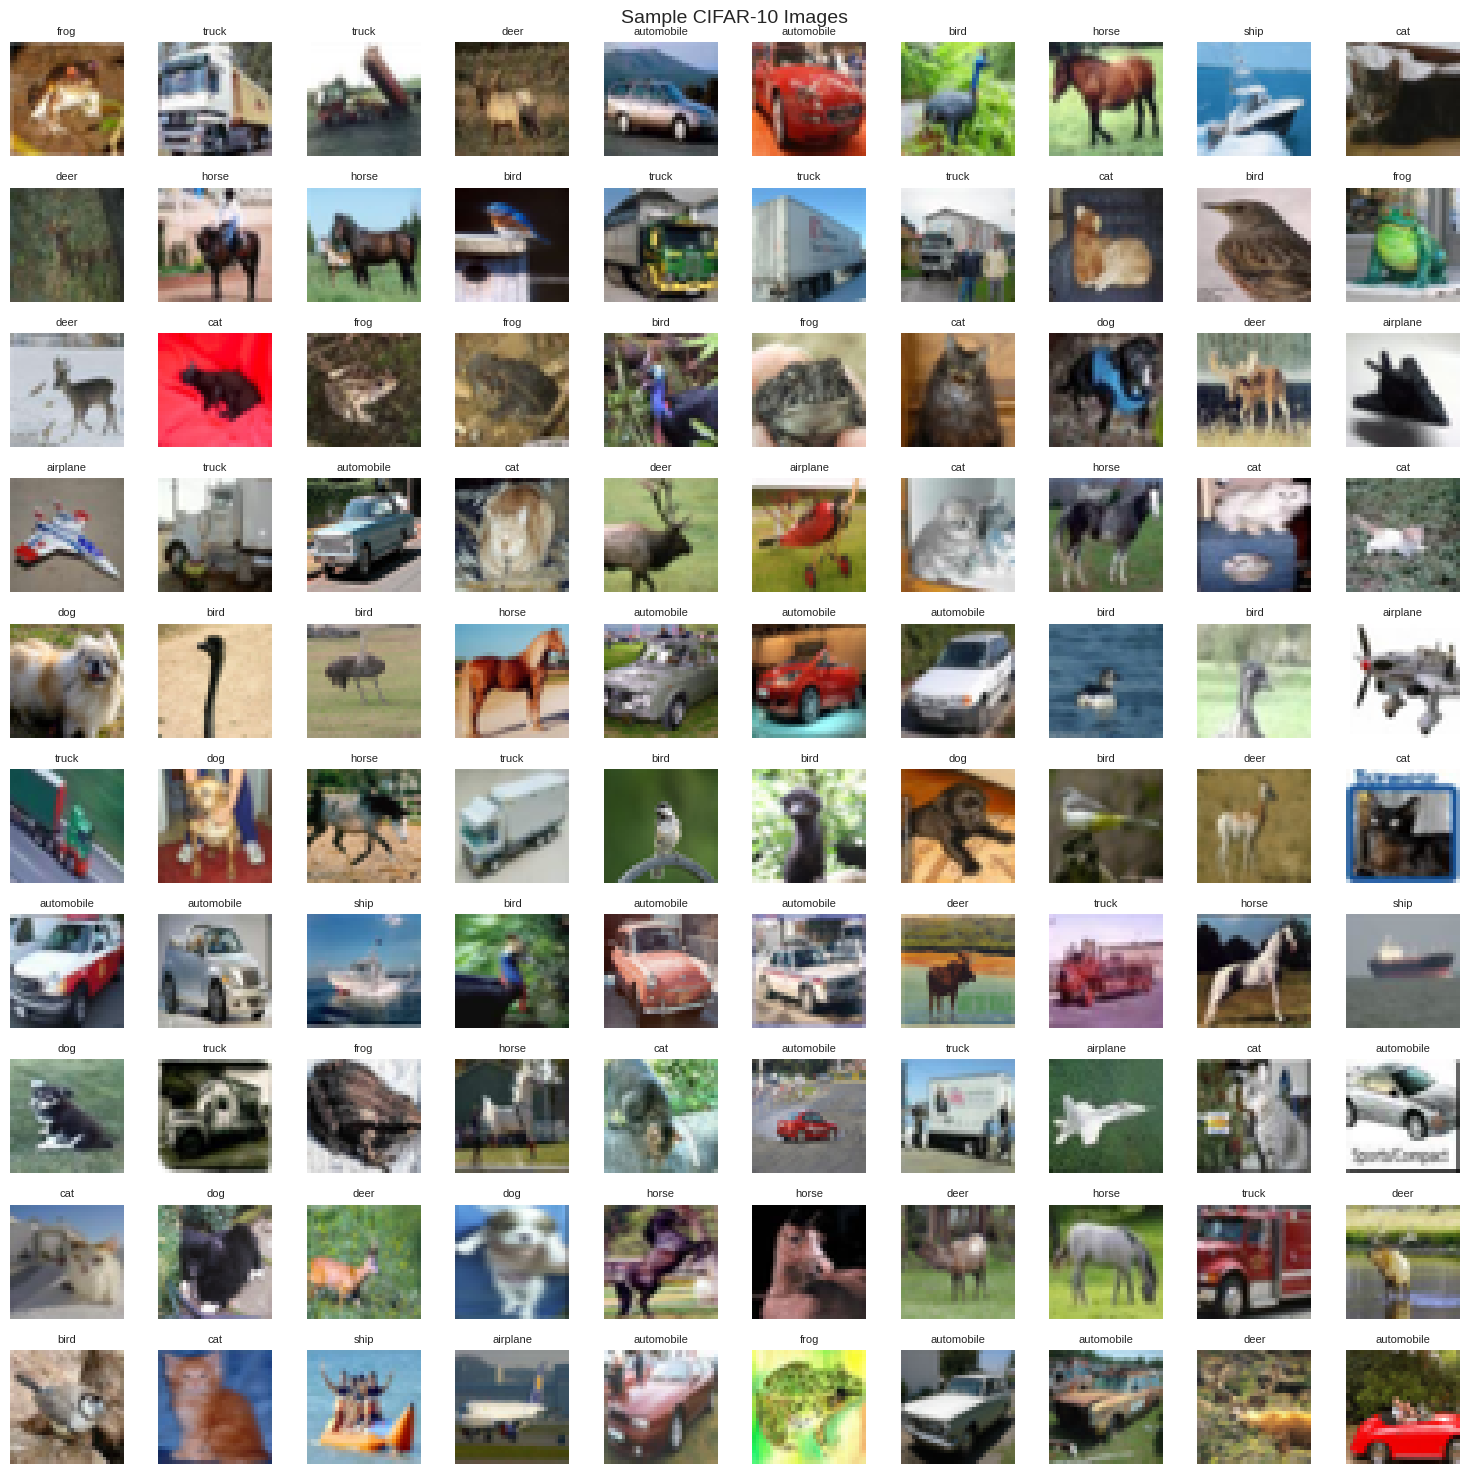

In [20]:
# Load CIFAR-10
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalize pixel values
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

# Convert labels
y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat = to_categorical(y_test_cifar, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set: {X_train_cifar.shape}")
print(f"Test set: {X_test_cifar.shape}")

# Visualize samples
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for i in range(100):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_train_cifar[i])
    ax.set_title(class_names[y_train_cifar[i][0]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

### Convolutional Neural Network (CNN)

For images, Convolutional layers are more effective than fully-connected layers:
- Local connectivity (spatial patterns)
- Weight sharing (translation invariance)
- Hierarchical feature learning

In [21]:
# Build CNN
cnn_cifar = keras.Sequential([
    # Convolutional layers
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== CNN Architecture ===")
cnn_cifar.summary()


=== CNN Architecture ===


/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [22]:
# Train (WARNING: This will take several minutes!)
print("\nTraining CNN on CIFAR-10...")
print("(This may take 5-10 minutes depending on your hardware)\n")

history_cifar = cnn_cifar.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    verbose=1
)

# Evaluate
test_loss, test_acc_cifar = cnn_cifar.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)
print(f"\n=== CIFAR-10 Results ===")
print(f"Test Accuracy: {test_acc_cifar:.2%}")


Training CNN on CIFAR-10...
(This may take 5-10 minutes depending on your hardware)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.4392 - loss: 1.6388 - val_accuracy: 0.5330 - val_loss: 1.3120
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6074 - loss: 1.1084 - val_accuracy: 0.6664 - val_loss: 0.9684
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.6726 - loss: 0.9370 - val_accuracy: 0.6964 - val_loss: 0.8743
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7063 - loss: 0.8398 - val_accuracy: 0.7270 - val_loss: 0.7898
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7350 - loss: 0.7642 - val_accuracy: 0.6944 - val_loss: 0.9149
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7518 - loss: 0.7145 - val_accuracy: 0.7678 - val_loss: 0.6667
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7702 - loss: 0.6662 - val_accuracy: 0.7546 - val_loss: 0.7101
Epoc

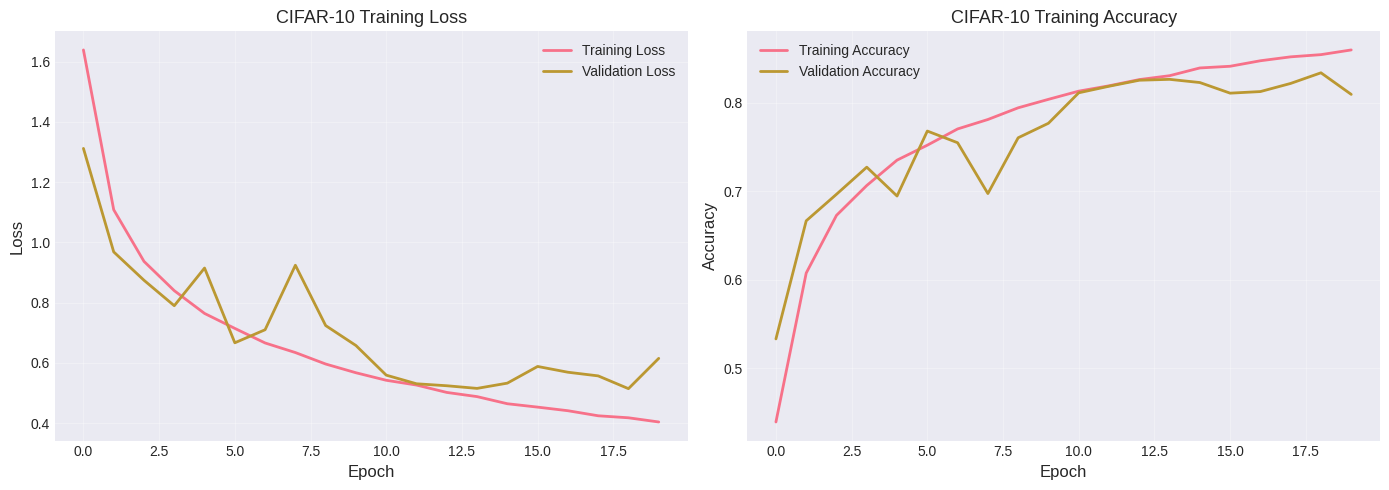

In [23]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cifar.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history_cifar.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('CIFAR-10 Training Loss', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_cifar.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history_cifar.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('CIFAR-10 Training Accuracy', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

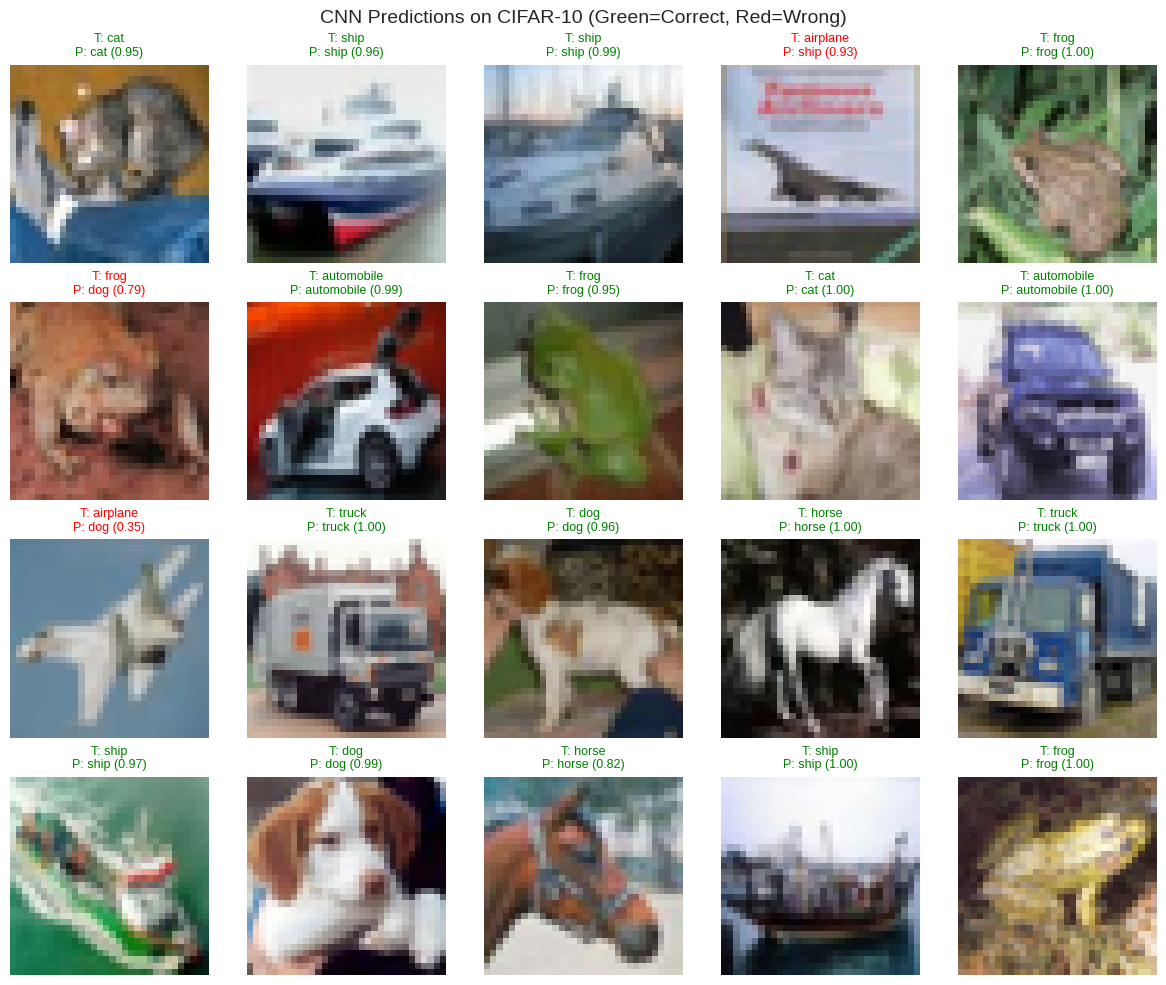

In [24]:
# Show predictions
n_show = 20
predictions_cifar = cnn_cifar.predict(X_test_cifar[:n_show], verbose=0)
predicted_classes_cifar = np.argmax(predictions_cifar, axis=1)
true_classes_cifar = y_test_cifar[:n_show].ravel()

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(n_show):
    axes[i].imshow(X_test_cifar[i])
    true_label = class_names[true_classes_cifar[i]]
    pred_label = class_names[predicted_classes_cifar[i]]
    confidence = predictions_cifar[i][predicted_classes_cifar[i]]

    color = 'green' if true_classes_cifar[i] == predicted_classes_cifar[i] else 'red'
    axes[i].set_title(f'T: {true_label}\nP: {pred_label} ({confidence:.2f})',
                     fontsize=9, color=color)
    axes[i].axis('off')

plt.suptitle('CNN Predictions on CIFAR-10 (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

### Physics: Predicting Pendulum Motion

Can an MLP learn the physics of a pendulum without knowing Newton's laws? Let's train a network to predict the angular position $\theta(t)$ given initial conditions.

For a simple pendulum: $\frac{d^2\theta}{dt^2} + \frac{g}{L}\sin(\theta) = 0$

In [25]:
# Generate pendulum training data
def pendulum_equations(state, t, g=9.8, L=1.0):
    theta, omega = state
    dtheta_dt = omega
    domega_dt = -(g/L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

# Generate trajectories
np.random.seed(42)
n_trajectories = 1000
t_span = np.linspace(0, 10, 200)

# Store trajectories for visualization
trajectories = []
X_pendulum = []
y_pendulum = []

for _ in range(n_trajectories):
    theta0 = np.random.uniform(-np.pi, np.pi)
    omega0 = np.random.uniform(-2, 2)

    solution = odeint(pendulum_equations, [theta0, omega0], t_span)
    theta_trajectory = solution[:, 0]
    trajectories.append((t_span, theta_trajectory, theta0, omega0))

    for i, t in enumerate(t_span):
        X_pendulum.append([t, theta0, omega0])
        y_pendulum.append(theta_trajectory[i])

X_pendulum = np.array(X_pendulum)
y_pendulum = np.array(y_pendulum)

print(f"Generated {len(X_pendulum)} training samples from {n_trajectories} trajectories")

# Split data
X_train_pend, X_test_pend, y_train_pend, y_test_pend = train_test_split(
    X_pendulum, y_pendulum, test_size=0.2, random_state=42
)

Generated 200000 training samples from 1000 trajectories


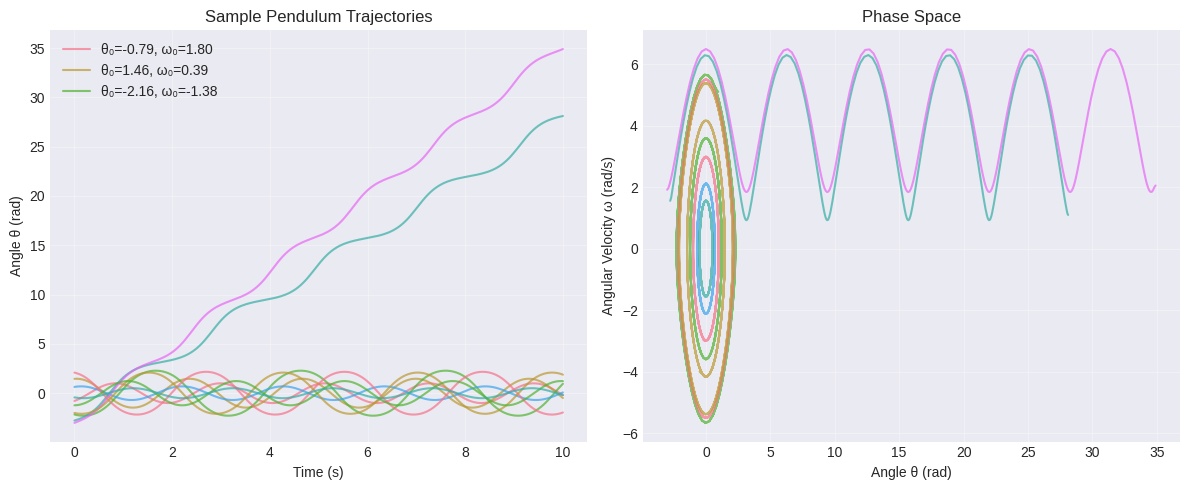

In [26]:
# Plot sample trajectories
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(min(10, len(trajectories))):
    t, theta, theta0, omega0 = trajectories[i]
    plt.plot(t, theta, alpha=0.7, label=f'θ₀={theta0:.2f}, ω₀={omega0:.2f}' if i < 3 else None)
plt.xlabel('Time (s)')
plt.ylabel('Angle θ (rad)')
plt.title('Sample Pendulum Trajectories')
plt.grid(True, alpha=0.3)
if len(trajectories) >= 3:
    plt.legend()

plt.subplot(1, 2, 2)
for i in range(min(10, len(trajectories))):
    t, theta, theta0, omega0 = trajectories[i]
    omega = np.gradient(theta, t)
    plt.plot(theta, omega, alpha=0.7)
plt.xlabel('Angle θ (rad)')
plt.ylabel('Angular Velocity ω (rad/s)')
plt.title('Phase Space')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Train MLP to learn pendulum dynamics
# Normalize inputs for better training
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_pend)
X_test_scaled = scaler_X.transform(X_test_pend)
y_train_scaled = scaler_y.fit_transform(y_train_pend.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test_pend.reshape(-1, 1))

# Build MLP with deeper architecture
mlp_pendulum = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(3,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

mlp_pendulum.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Training MLP on pendulum dynamics...")
# Add early stopping
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_pend = mlp_pendulum.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.15,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
test_loss_pend, test_mae = mlp_pendulum.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"\nTest MSE: {test_loss_pend:.6f}")
print(f"Test MAE: {test_mae:.6f}")

Training MLP on pendulum dynamics...
Epoch 1/300


/home/aythami-beth/ull/modelizacion/notebooks/modelisation_practice/.modelisation_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2125/2125 ━━━━━━━━━━━━━━━━━━━━ 2s 698us/step - loss: 0.2019 - mae: 0.2542 - val_loss: 0.0813 - val_mae: 0.1852
Epoch 2/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 2s 798us/step - loss: 0.0918 - mae: 0.1741 - val_loss: 0.0667 - val_mae: 0.1678
Epoch 3/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - loss: 0.0758 - mae: 0.1520 - val_loss: 0.0571 - val_mae: 0.1450
Epoch 4/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 2s 747us/step - loss: 0.0648 - mae: 0.1374 - val_loss: 0.0407 - val_mae: 0.1208
Epoch 5/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 2s 814us/step - loss: 0.0605 - mae: 0.1289 - val_loss: 0.0321 - val_mae: 0.1087
Epoch 6/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 1s 614us/step - loss: 0.0526 - mae: 0.1194 - val_loss: 0.0488 - val_mae: 0.1175
Epoch 7/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 2s 725us/step - loss: 0.0479 - mae: 0.1140 - val_loss: 0.0286 - val_mae: 0.1054
Epoch 8/300
2125/2125 ━━━━━━━━━━━━━━━━━━━━ 2s 842us/step - loss: 0.0456 - mae: 0.1100 - val_loss: 0.0274 - val_mae: 0.0953
Epoch 9/300
2125/2125 ━━━━━━

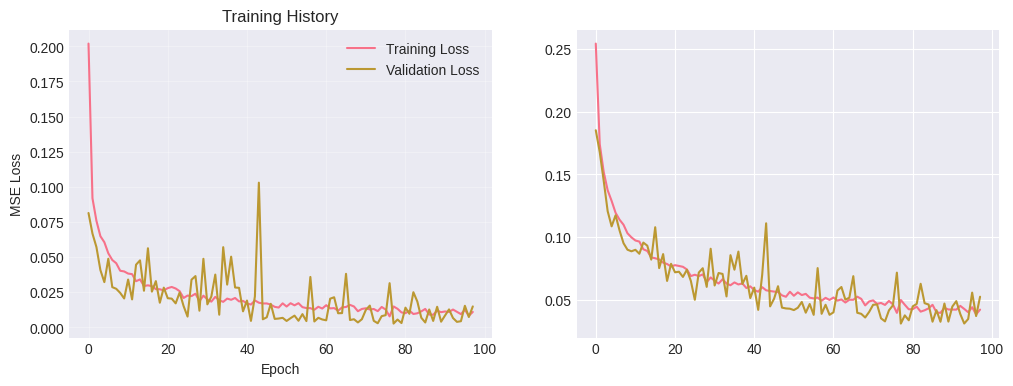

In [28]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_pend.history['loss'], label='Training Loss')
plt.plot(history_pend.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_pend.history['mae'], label='Training MAE')

plt.plot(history_pend.history['val_mae'], label='Validation MAE')
plt.show()

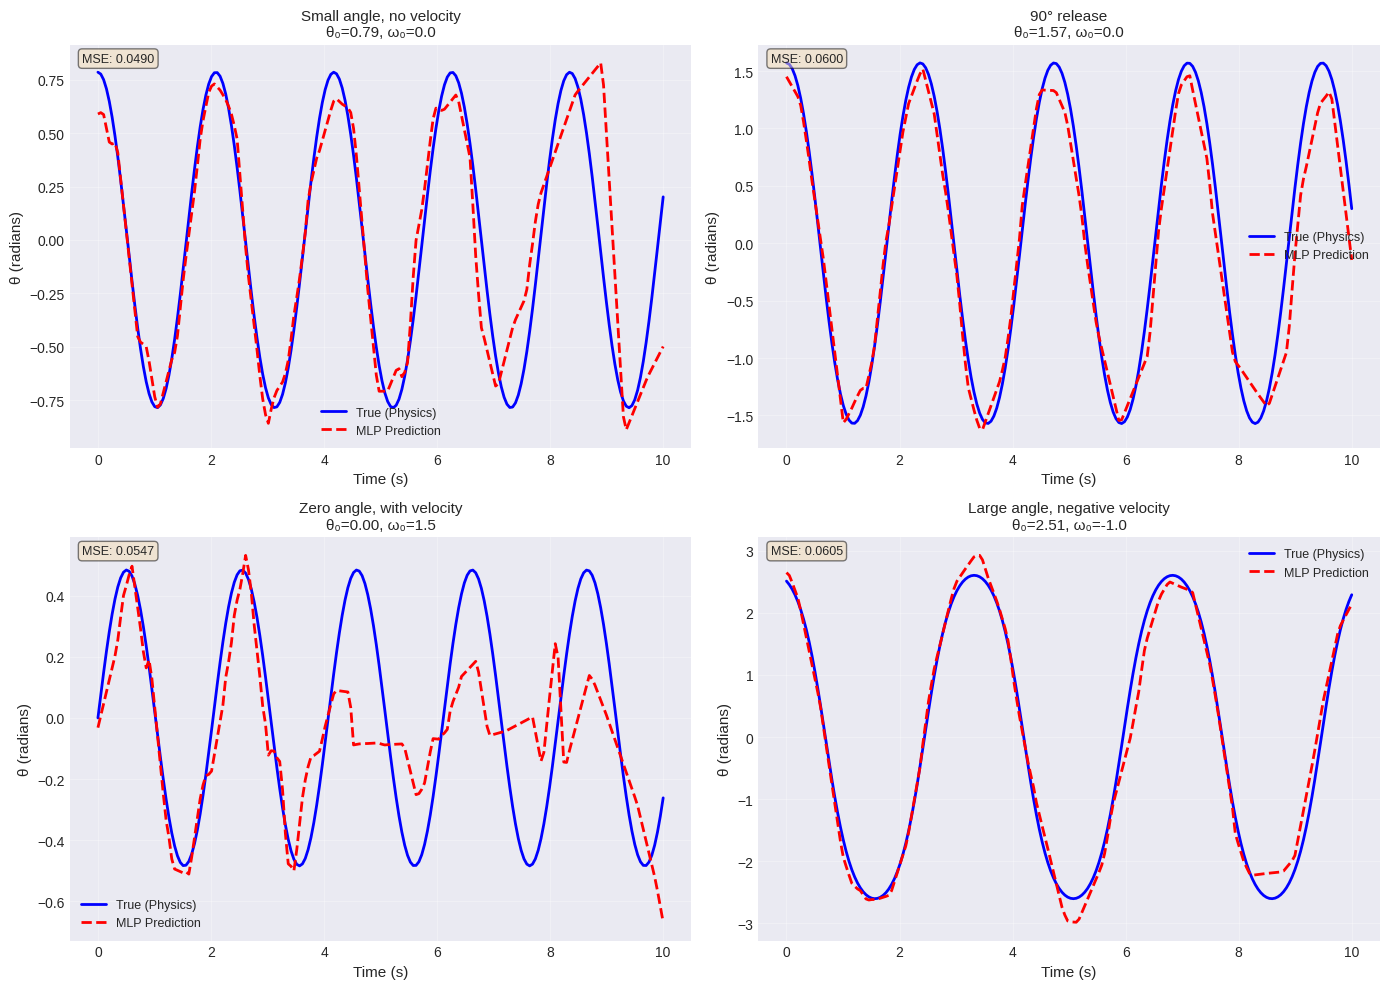

In [29]:
# Test on new initial conditions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

test_conditions = [
    (np.pi/4, 0, "Small angle, no velocity"),
    (np.pi/2, 0, "90° release"),
    (0, 1.5, "Zero angle, with velocity"),
    (np.pi*0.8, -1, "Large angle, negative velocity")
]

for idx, (theta0, omega0, title) in enumerate(test_conditions):
    # True solution
    solution_true = odeint(pendulum_equations, [theta0, omega0], t_span)
    theta_true = solution_true[:, 0]

    # MLP prediction
    X_pred = np.array([[t, theta0, omega0] for t in t_span])
    X_pred_scaled = scaler_X.transform(X_pred)
    theta_pred_scaled = mlp_pendulum.predict(X_pred_scaled, verbose=0)
    theta_pred = scaler_y.inverse_transform(theta_pred_scaled).ravel()

    # Plot
    axes[idx].plot(t_span, theta_true, 'b-', linewidth=2, label='True (Physics)')
    axes[idx].plot(t_span, theta_pred, 'r--', linewidth=2, label='MLP Prediction')
    axes[idx].set_xlabel('Time (s)', fontsize=11)
    axes[idx].set_ylabel('θ (radians)', fontsize=11)
    axes[idx].set_title(f'{title}\nθ₀={theta0:.2f}, ω₀={omega0:.1f}', fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

    # Calculate error
    mse = mean_squared_error(theta_true, theta_pred)
    axes[idx].text(0.02, 0.98, f'MSE: {mse:.4f}',
                  transform=axes[idx].transAxes, fontsize=9,
                  verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()